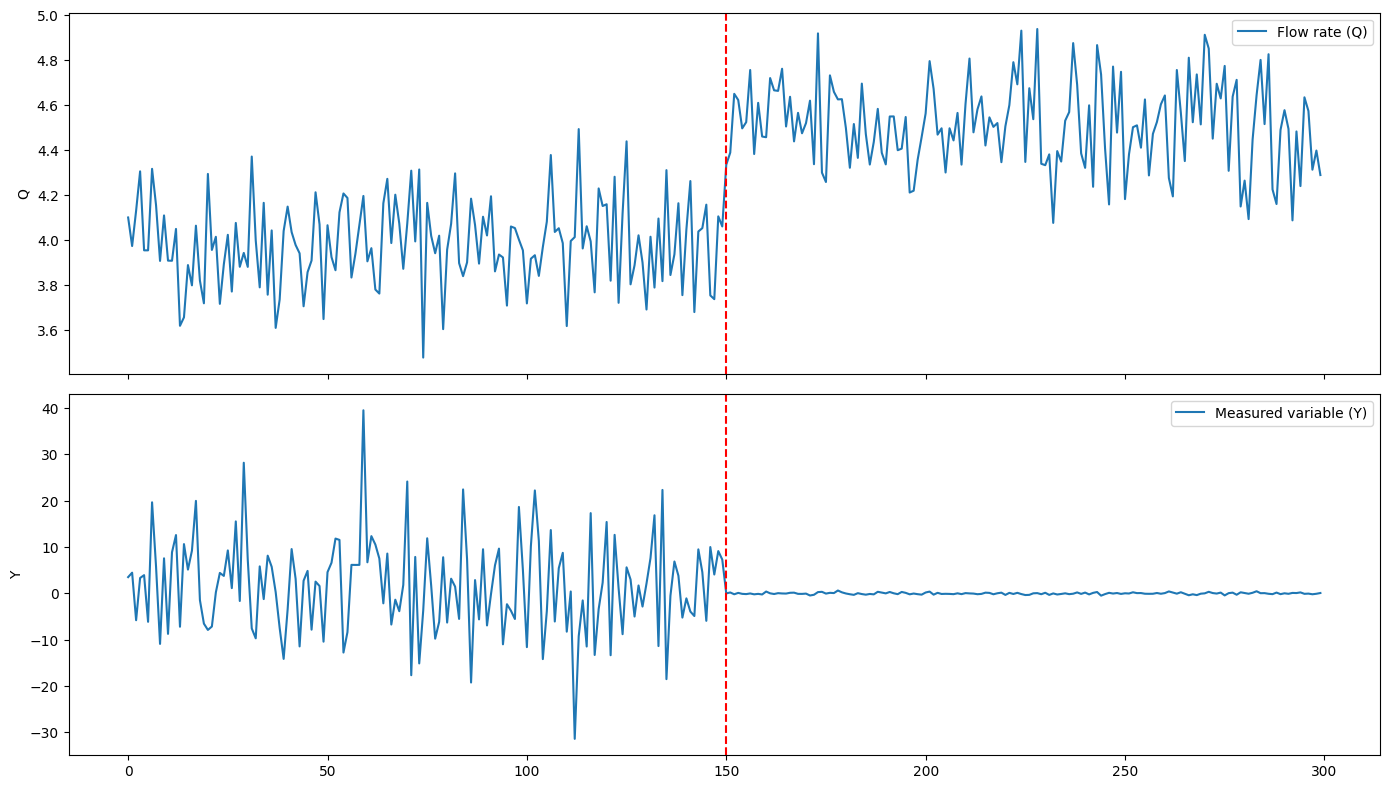

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from BOCPD import bocpd_multivariate
np.random.seed(42)

n_normal = 150
n_leak = 150

# Normal regime
Q1 = np.random.normal(4, 0.2, n_normal)
Y1 = np.random.normal(1, 10, n_normal)

# Leak regime
Q2 = np.random.normal(4.5, 0.2, n_leak)
Y2 = np.random.normal(0, 0.2, n_leak)

Q = np.concatenate([Q1, Q2])
Y = np.concatenate([Y1, Y2])

true_cp = n_normal

Q_norm = (Q - np.mean(Q)) / np.std(Q)
Y_norm = (Y - np.mean(Y)) / np.std(Y)
dQ = np.gradient(Q_norm)

dY = np.gradient(Y_norm)

X = np.column_stack([Q_norm, dQ, Y_norm, dY])

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax[0].plot(Q, label="Flow rate (Q)")
ax[0].axvline(true_cp, color="red", ls="--")
ax[0].set_ylabel("Q")
ax[0].legend()

ax[1].plot(Y, label="Measured variable (Y)")
ax[1].axvline(true_cp, color="red", ls="--")
ax[1].set_ylabel("Y")
ax[1].legend()
plt.tight_layout()
plt.show()

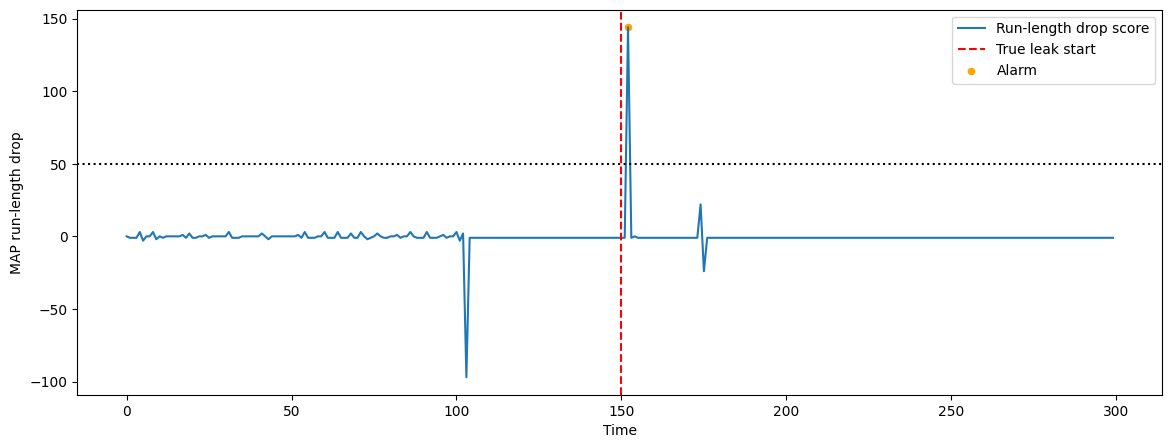

Alarm first triggered at t=152


In [ ]:



cp_probs, R = bocpd_multivariate(X, hazard=1 / 50)

# R[0, t] is always ~hazard after normalization, so thresholding cp_probs cannot work.
# Use MAP run-length collapse at the changepoint instead.
map_rl = np.argmax(R[:, 1:], axis=0)
rl_drop = -np.diff(map_rl, prepend=map_rl[0])
cp_probs = rl_drop.astype(float)

threshold = 50
alarm = rl_drop >= threshold



plt.figure(figsize=(14, 5))
plt.plot(cp_probs, label="Run-length drop score")
plt.axvline(true_cp, color="red", linestyle="--", label="True leak start")
plt.axhline(threshold, color="black", linestyle=":")
plt.scatter(np.where(alarm)[0], cp_probs[alarm], color="orange", s=20, label="Alarm")
plt.ylabel("MAP run-length drop")
plt.xlabel("Time")
plt.legend()
plt.show()

alarm_idx = np.where(alarm)[0]
if len(alarm_idx) > 0:
    print(f"Alarm first triggered at t={alarm_idx[0]}")
else:
    print("No alarm triggered")